<a href="https://colab.research.google.com/github/RithwikRajSuram/Flight-Price-Classification/blob/main/Flight_Price_Classification_using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
data=pd.read_csv('/content/Data-Week8 (1).csv')
data.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,Destination,price
0,11/2/2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953
1,11/2/2022,SpiceJet,SG,8157,6:20,Delhi,02h 20m,non-stop,8:40,Mumbai,5953


In [9]:
from sklearn.datasets import load_iris
iris = load_iris()
X=iris.data[:,:2]
y=iris.target

In [12]:
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.metrics import accuracy_score
# linear kernel
svc=svm.SVC(kernel='linear', C=1).fit(X,y)
svc_pred=svc.predict(X)
print('svc accuracy', accuracy_score(y,svc_pred)*100)
# linear kernel
lin_svc=svm.LinearSVC(C=1).fit(X,y)
lin_pred=lin_svc.predict(X)
print('svc accuracy', accuracy_score(y,lin_pred)*100)
#rbf kernel
rbf_svc=svm.SVC(kernel='rbf', gamma=.7, C=1).fit(X,y)
rbf_pred=rbf_svc.predict(X)
print('rbf accuracy', accuracy_score(y,rbf_pred)*100)
pol_svc=svm.SVC(kernel='poly', degree=3, C=1).fit(X,y)
pol_pred=pol_svc.predict(X)
print('pol accuracy', accuracy_score(y,pol_pred)*100)

svc accuracy 82.0
svc accuracy 80.0
rbf accuracy 82.66666666666667
pol accuracy 81.33333333333333


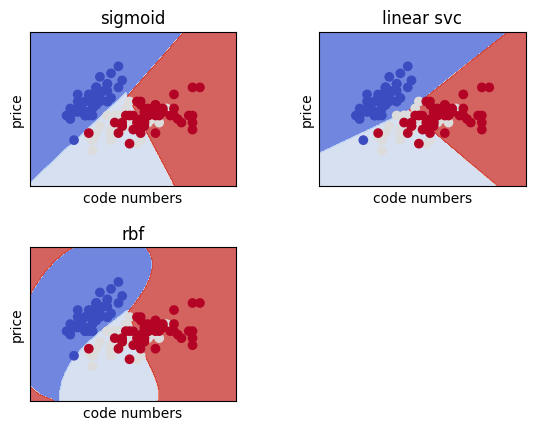

In [15]:
import numpy as np
import matplotlib.pyplot as plt
h=0.02
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 # num_code over x axis
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1 # price over y axis
xx, yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

titles=['sigmoid','linear svc','rbf','poly']

for i, clf in enumerate((svc, lin_svc, rbf_svc)):
    # create 4 subplots
    plt.subplot(2,2,i+1)
    plt.subplots_adjust(wspace=0.4,hspace=0.4)

    # predict destinations based on num_code and price
    Z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    # plot actual and predicted values
    plt.contourf(xx,yy,Z,cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:,0],X[:,1], c=y, cmap=plt.cm.coolwarm)

    # modify the graphs by adding labels, titles, ...
    plt.xlabel('code numbers')
    plt.ylabel('price')
    plt.xlim(xx.min(),xx.max())
    plt.ylim(yy.min(),yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()